# Dataset Exploration

## Dataset

RAVDESS

## Objectives

- Explore dataset
- Understand file naming
- Count emotions
- Count actors
- Count samples
- Visualize distribution

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataset_path = "../datasets/RAVDESS"
print(dataset_path)

../datasets/RAVDESS


In [6]:
actors = sorted([
    folder
    for folder in os.listdir(dataset_path)
    if folder.startswith("Actor_")
])

print("Total Actors :", len(actors))
print(actors)

Total Actors : 24
['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']


In [8]:
import os
import pandas as pd

emotion_dict = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fearful",
    "07": "Disgust",
    "08": "Surprised"
}

data = []

for actor in actors:

    actor_path = os.path.join(dataset_path, actor)

    for file in os.listdir(actor_path):

        if file.endswith(".wav"):

            emotion_code = file.split("-")[2]

            data.append({
                "Actor": actor,
                "Filename": file,
                "Emotion_Code": emotion_code,
                "Emotion": emotion_dict[emotion_code]
            })

df = pd.DataFrame(data)

df.head()

,Actor,Filename,Emotion_Code,Emotion
0,Actor_01,03-01-01-01-01-01-01.wav,01,Neutral
1,Actor_01,03-01-01-01-01-02-01.wav,01,Neutral
2,Actor_01,03-01-01-01-02-01-01.wav,01,Neutral
3,Actor_01,03-01-01-01-02-02-01.wav,01,Neutral
4,Actor_01,03-01-02-01-01-01-01.wav,02,Calm


In [9]:
print("Total Audio Files :", len(df))

Total Audio Files : 1440


In [10]:
df["Emotion"].value_counts()

Emotion
Calm         192
Happy        192
Sad          192
Angry        192
Fearful      192
Disgust      192
Surprised    192
Neutral       96
Name: count, dtype: int64

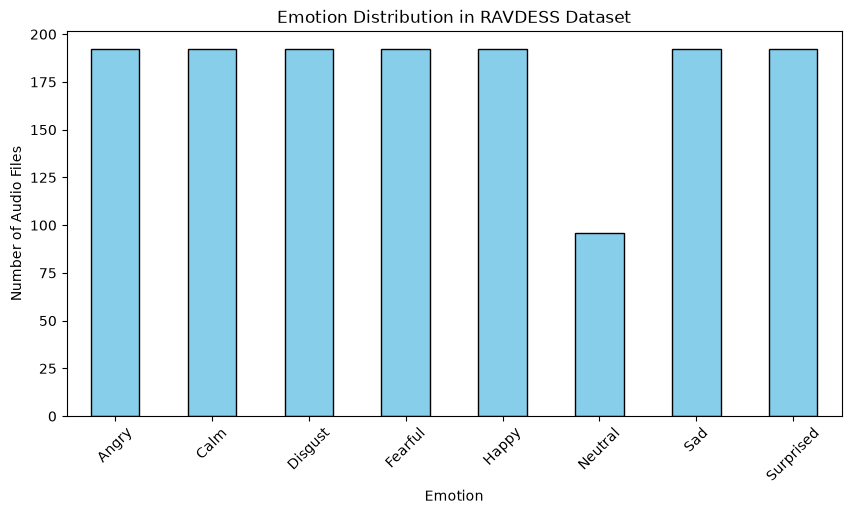

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df["Emotion"].value_counts().sort_index().plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Emotion Distribution in RAVDESS Dataset")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)

plt.show()